In [ ]:
!pip install -q pyomo

In [ ]:
# https://jckantor.github.io/ND-Pyomo-Cookbook/notebooks/01.02-Running-Pyomo-on-Google-Colab.html#installing-pyomo-and-solvers
%%capture
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

In [ ]:
import pyomo.environ as pyo
import numpy as np

def simulation(params, alphas, criteria='demand'):

    # ------------------------
    # Helper: solve one alpha
    # ------------------------
    def solve_one_alpha(alpha, delta_x):
        a = params["a"]
        b = params["b"]
        pi = params["pi"]
        Dbar = np.array(params["Dbar"], dtype=float)
        Ds = params["Ds"]
        n = len(Dbar)

        m = pyo.ConcreteModel()
        m.I = pyo.RangeSet(0, n-1)

        # variables (0 ≤ D_i ≤ Dbar_i)
        m.D = pyo.Var(m.I, bounds=lambda m,i: (0, float(Dbar[i])))

        # price
        def price(m, i):
            return a * m.D[i] + (b - a * Dbar[i])

        # objective: profit
        def obj_rule(m):
            return pi * sum(m.D[i] for i in m.I) \
                   - sum(price(m,i) * m.D[i] for i in m.I)
        m.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)

        # capacity
        m.cap = pyo.Constraint(expr=sum(m.D[i] for i in m.I) <= Ds)

        # fairness bound
        bound = (1 - alpha) * delta_x

        # fairness: |Di/Dbar_i - Dj/Dbar_j| ≤ bound
        def f_up(m, i, j):
            return  m.D[i]/Dbar[i] - m.D[j]/Dbar[j] <= bound
        def f_dn(m, i, j):
            return -(m.D[i]/Dbar[i] - m.D[j]/Dbar[j]) <= bound

        m.fair_up = pyo.Constraint(m.I, m.I,
            rule=lambda m,i,j: f_up(m,i,j) if i < j else pyo.Constraint.Skip)
        m.fair_dn = pyo.Constraint(m.I, m.I,
            rule=lambda m,i,j: f_dn(m,i,j) if i < j else pyo.Constraint.Skip)

        # solve
        solver = pyo.SolverFactory("ipopt")
        solver.solve(m, tee=False)

        # extract solution
        D = np.array([pyo.value(m.D[i]) for i in m.I])
        p = a*D + (b - a*Dbar)
        U = 0.5*a*D**2
        profit = pyo.value(m.obj)

        return dict(D=D, p=p, U=U, profit=profit)

    # ============================================
    # STEP 1: baseline alpha=0 → compute delta_x
    # ============================================
    sol0 = solve_one_alpha(alpha=0, delta_x=1e6)  # ignore fairness
    D0 = sol0["D"]
    Dbar = np.array(params["Dbar"], dtype=float)

    # demand fairness baseline Δ
    delta_x = max(
        abs(D0[i]/Dbar[i] - D0[j]/Dbar[j])
        for i in range(len(Dbar)) for j in range(i+1, len(Dbar))
    )

    # ============================================
    # STEP 2: loop over alphas and store results
    # ============================================
    res = {"alpha": [], "D": [], "p": [], "U": [], "profit": []}

    for alpha in alphas:
        sol = solve_one_alpha(alpha, delta_x)

        res["alpha"].append(alpha)
        res["D"].append(sol["D"])
        res["p"].append(sol["p"])
        res["U"].append(sol["U"])
        res["profit"].append(sol["profit"])

    return res


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def draw_plot(params, res, ncol=3, regime_bounds = []):
    alpha_list = np.array(res["alpha"])
    n = len(res["D"][0])   # number of customers

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    lw = 2

    # ---------------------------------------------------------
    # 1. Profit, total utility, NSW
    # ---------------------------------------------------------
    profit_list = np.array(res["profit"])
    U_total_list = np.array([np.sum(U) for U in res["U"]])

    # NSW = sum log U_i (we assume you computed it separately or we recompute)
    NSW_list, SW_list = [], []
    for i in range(len(res["U"])):
        U = res["U"][i]
        Pi = res["profit"][i]
        if np.all(U > 0):
            NSW_list.append(np.sum(np.log(U)))
        else:
            NSW_list.append(-np.inf)
        SW_list.append(np.sum(U) + Pi)
    NSW_list = np.array(NSW_list)
    SW_list = np.array(SW_list)

    axs[0].plot(alpha_list, profit_list, 'r', label=r'$\Pi$', linewidth=lw)
    axs[0].plot(alpha_list, NSW_list, color='purple', label=r'$W_{CNW}$', linewidth=lw)
    axs[0].plot(alpha_list, U_total_list, 'g', label='U', linewidth=lw)
    axs[0].plot(alpha_list, SW_list, color='blue', label=r'$W_{SW}$', linewidth=lw)


    # ---------------------------------------------------------
    # 2. Prices p_i
    # ---------------------------------------------------------
    p_mat = np.array(res["p"])   # shape (len(alpha), n)

    colors = ['tab:orange', 'tab:blue', 'tab:green']#plt.cm.tab20(np.linspace(0, 1, n))
    for i in range(n):
        axs[1].plot(alpha_list, p_mat[:, i], label=fr'$p_{i+1}$', linewidth=lw, color=colors[i])


    # ---------------------------------------------------------
    # 3. Demands D_i with dashed Dbar_i
    # ---------------------------------------------------------
    D_mat = np.array(res["D"])   # shape (len(alpha), n)
    Dbar = np.array(params["Dbar"])

    for i in range(n):
        axs[2].plot(alpha_list, D_mat[:, i], label=fr'$D_{i+1}$', linewidth=lw, color=colors[i])
        axs[2].axhline(Dbar[i], ls='--', linewidth=1.5, color=colors[i])


    # ---------------------------------------------------------
    # 4. Utilities U_i
    # ---------------------------------------------------------
    U_mat = np.array(res["U"])

    for i in range(n):
        axs[3].plot(alpha_list, U_mat[:, i], label=fr'$U_{i+1}$', linewidth=lw, color=colors[i])


    # ---------------------------------------------------------
    # Formatting for all panels
    # ---------------------------------------------------------
    for i in range(4):
        axs[i].set_xlim(0, 1)
        axs[i].legend(
            loc='lower center',
            bbox_to_anchor=(0.5, 1.02),
            ncol=ncol if i != 0 else 2,
            fontsize=18,
            frameon=True
        )
        axs[i].set_xlabel(r'$\alpha$', fontsize=24)

    if len(regime_bounds) > 0:
      for i in range(4):
        for bound in regime_bounds:
          axs[i].axvline(bound, color='gray', linestyle='--', linewidth=1.5)

    plt.tight_layout()
    plt.show()


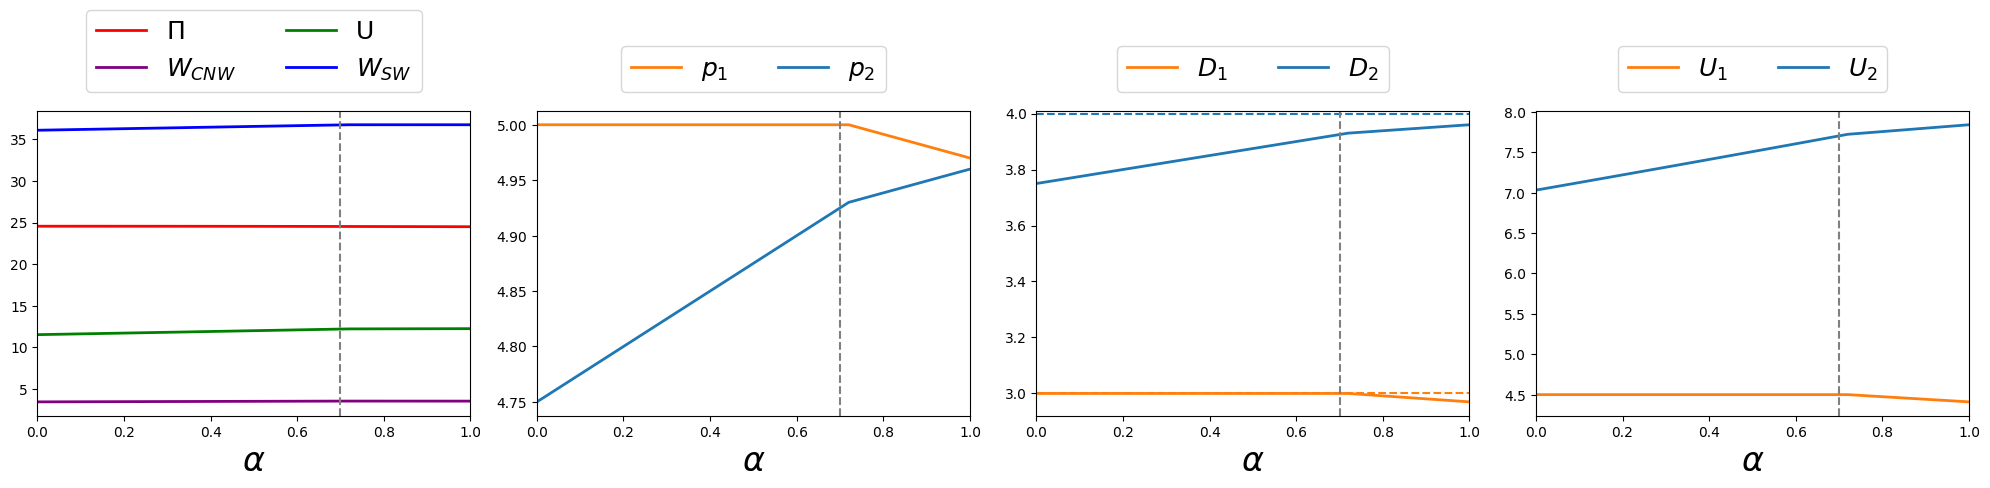

In [ ]:
params = dict(
    a = 1.0,
    b = 5.0,
    pi = 8.5,
    Dbar = [3,4],
    Ds = 6.93
)

alphas = [i/50 for i in range(51)]

res = simulation(params, alphas)

draw_plot(params, res, ncol=2, regime_bounds=[0.7])


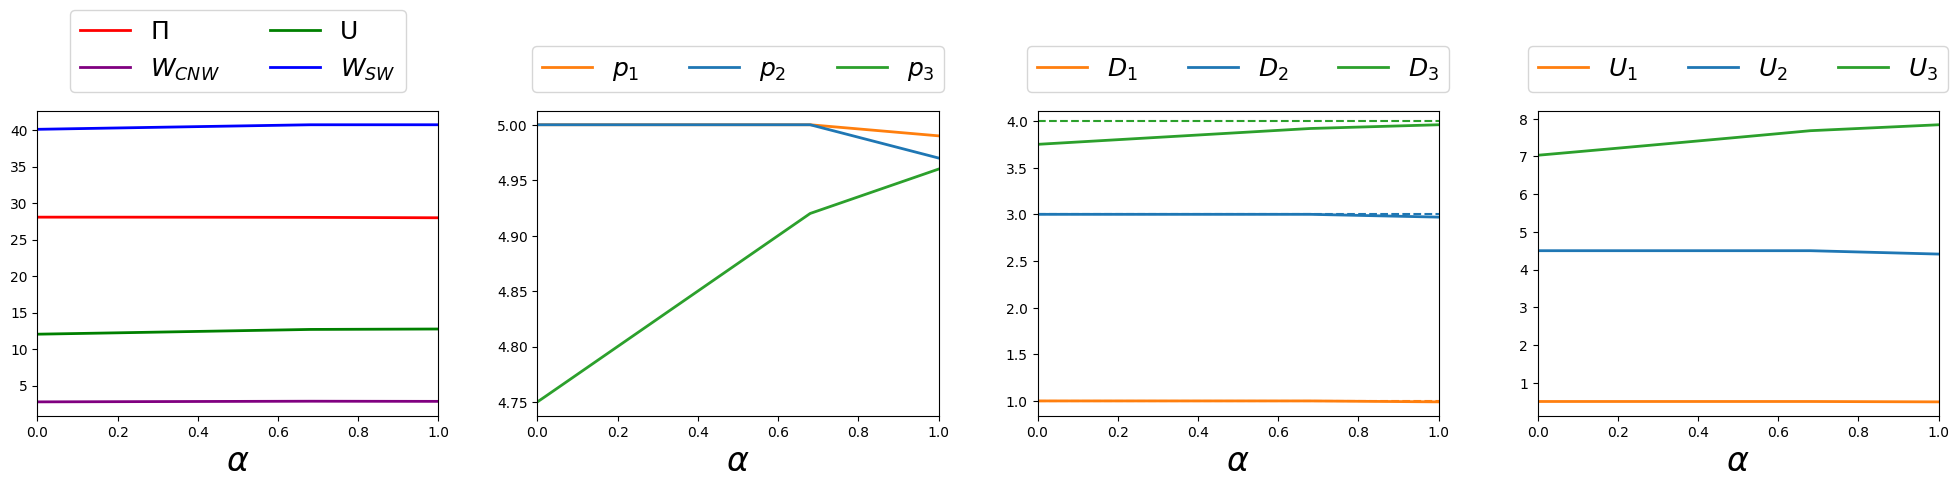

In [ ]:
params = dict(
    a = 1.0,
    b = 5.0,
    pi = 8.5,
    Dbar = [1,3,4],
    Ds = 7.92
)

alphas = [i/50 for i in range(51)]

res = simulation(params, alphas)

draw_plot(params, res, ncol=3)
